In [1]:
# ============================================
# CELDA 1: Importaciones
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas")

✅ Librerías importadas


In [2]:
# ============================================
# CELDA 2: Carga de datos
# ============================================
df = pd.read_csv('../data/secom.data',
                 sep=' ', header=None)

labels = pd.read_csv('../data/secom_labels.data',
                     sep=' ', header=None,
                     usecols=[0], names=['label'])

df['label'] = labels['label']

print(f"✅ Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]-1} sensores")

✅ Dataset cargado: 1,567 filas x 590 sensores


In [3]:
# ============================================
# CELDA 3: Eliminar sensores con demasiados faltantes
# ============================================

# Separamos sensores de etiqueta
X = df.drop(columns=['label'])
y = df['label']

# Calculamos % faltante por sensor
missing_pct = X.isnull().mean()

# Eliminamos sensores con más del 50% de datos faltantes
THRESHOLD_MISSING = 0.50
cols_to_drop = missing_pct[missing_pct > THRESHOLD_MISSING].index

X_clean = X.drop(columns=cols_to_drop)

print(f"📊 Sensores originales    : {X.shape[1]}")
print(f"📊 Sensores eliminados    : {len(cols_to_drop)}")
print(f"📊 Sensores restantes     : {X_clean.shape[1]}")

📊 Sensores originales    : 590
📊 Sensores eliminados    : 28
📊 Sensores restantes     : 562


In [4]:
# ============================================
# CELDA 4: Imputación de valores faltantes
# ============================================

# Rellenamos los faltantes restantes con la mediana
# Usamos mediana (no promedio) porque es más robusta
# ante valores extremos — importante en datos de fallas

X_imputed = X_clean.fillna(X_clean.median())

# Verificamos que no queden faltantes
remaining_nulls = X_imputed.isnull().sum().sum()

print(f"✅ Imputación completada")
print(f"📊 Valores faltantes restantes: {remaining_nulls}")
print(f"📊 Shape final: {X_imputed.shape}")

✅ Imputación completada
📊 Valores faltantes restantes: 0
📊 Shape final: (1567, 562)


In [5]:
# ============================================
# CELDA 5: Eliminar sensores constantes
# ============================================

# Un sensor que siempre da el mismo valor
# no detecta nada — es ruido puro
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_imputed)

cols_kept = X_imputed.columns[selector.get_support()]
X_var_df  = pd.DataFrame(X_var, columns=cols_kept)

print(f"📊 Sensores antes : {X_imputed.shape[1]}")
print(f"📊 Sensores después: {X_var_df.shape[1]}")
print(f"📊 Eliminados (sin variación): "
      f"{X_imputed.shape[1] - X_var_df.shape[1]}")

📊 Sensores antes : 562
📊 Sensores después: 297
📊 Eliminados (sin variación): 265


In [6]:
# ============================================
# CELDA 6: Normalización con StandardScaler
# ============================================

# En anomaly detection usamos StandardScaler
# (no MinMax como en el proyecto anterior)
# porque Isolation Forest es sensible a la escala
# y StandardScaler maneja mejor los outliers

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_var_df)
X_scaled = pd.DataFrame(X_scaled, columns=X_var_df.columns)

print(f"✅ Normalización aplicada")
print(f"📊 Shape final  : {X_scaled.shape}")
print(f"\nEstadísticas después de escalar:")
print(X_scaled.describe().loc[['mean', 'std']].round(3).iloc[:, :5])
print("(mostrando primeros 5 sensores)")

✅ Normalización aplicada
📊 Shape final  : (1567, 297)

Estadísticas después de escalar:
        0    1    2    3    4
mean  0.0 -0.0 -0.0 -0.0  0.0
std   1.0  1.0  1.0  1.0  1.0
(mostrando primeros 5 sensores)


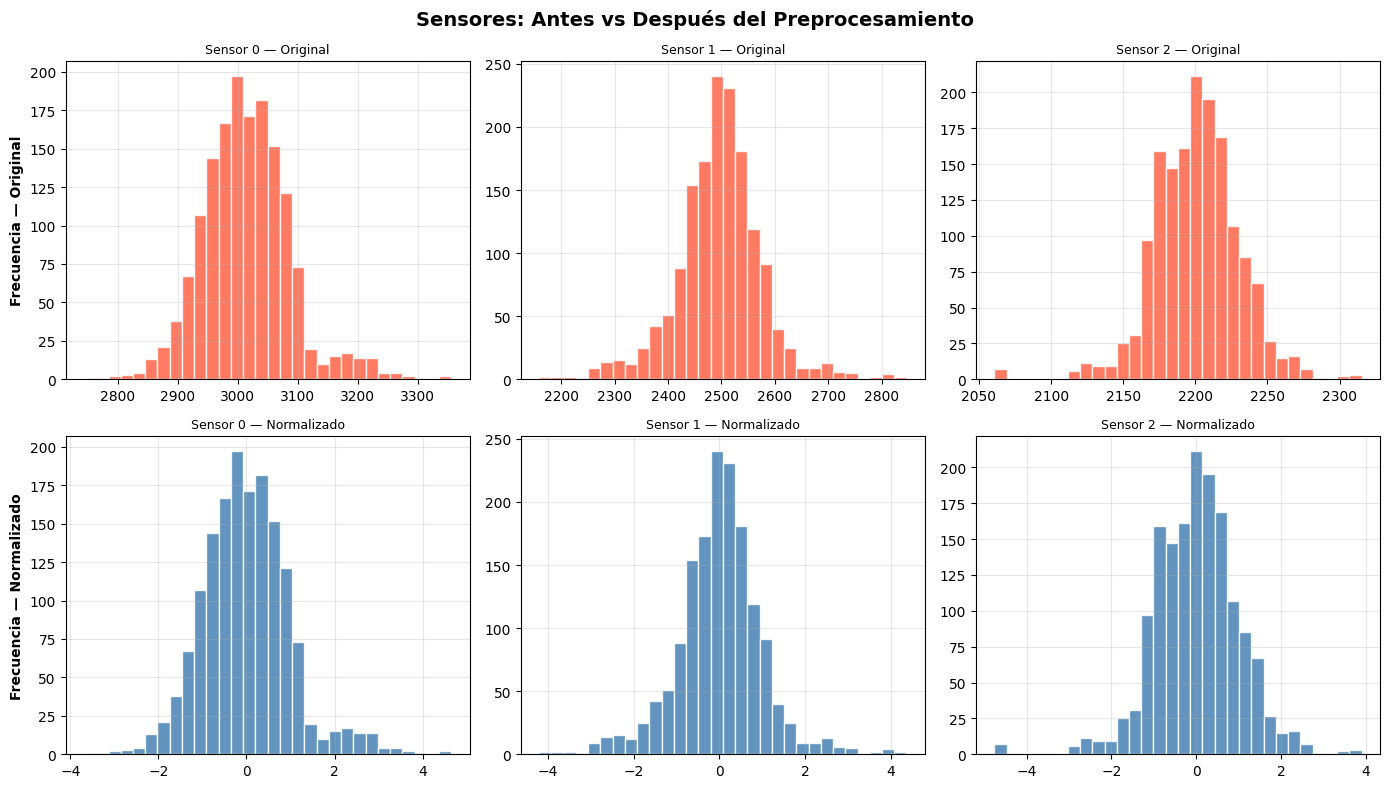

✅ Gráfica guardada


In [7]:
# ============================================
# CELDA 7: Comparación antes vs después
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Sensores: Antes vs Después del Preprocesamiento',
             fontsize=14, fontweight='bold')

sample_cols = X_scaled.columns[:3]

for i, col in enumerate(sample_cols):
    # Antes — datos originales
    axes[0, i].hist(X_imputed[col].dropna(), bins=30,
                    color='tomato', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'Sensor {col} — Original', fontsize=9)
    axes[0, i].grid(True, alpha=0.3)

    # Después — datos normalizados
    axes[1, i].hist(X_scaled[col], bins=30,
                    color='steelblue', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'Sensor {col} — Normalizado', fontsize=9)
    axes[1, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Frecuencia — Original', fontweight='bold')
axes[1, 0].set_ylabel('Frecuencia — Normalizado', fontweight='bold')

plt.tight_layout()
plt.savefig('../src/preprocessing_comparison.png', dpi=150)
plt.show()
print("✅ Gráfica guardada")

In [8]:
# ============================================
# CELDA 8: Guardar datos procesados
# ============================================
import pickle
import os

# Guardamos el dataset limpio
X_scaled.to_csv('../data/X_processed.csv', index=False)
y.to_csv('../data/y_labels.csv', index=False)

# Guardamos el scaler para usarlo en Streamlit
os.makedirs('../src/model', exist_ok=True)
with open('../src/model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardamos columnas que sobrevivieron el filtro
cols_final = list(X_scaled.columns)
with open('../src/model/feature_cols.pkl', 'wb') as f:
    pickle.dump(cols_final, f)

print("✅ Archivos guardados:")
print(f"   data/X_processed.csv     — {X_scaled.shape}")
print(f"   data/y_labels.csv        — {y.shape}")
print(f"   src/model/scaler.pkl     — StandardScaler")
print(f"   src/model/feature_cols.pkl — {len(cols_final)} sensores")

✅ Archivos guardados:
   data/X_processed.csv     — (1567, 297)
   data/y_labels.csv        — (1567,)
   src/model/scaler.pkl     — StandardScaler
   src/model/feature_cols.pkl — 297 sensores


In [9]:
# ============================================
# CELDA 9: Resumen
# ============================================

print("=" * 50)
print("RESUMEN — Preprocessing Completo")
print("=" * 50)
print(f"""
Pasos aplicados:
  1. Eliminados sensores con >50% faltantes
  2. Imputación con mediana
  3. Eliminados sensores sin variación
  4. Normalización con StandardScaler

Reducción de dimensionalidad:
  Sensores originales  : 590
  Sensores finales     : {X_scaled.shape[1]}
  Reducción            : {590 - X_scaled.shape[1]} sensores eliminados
  
Muestras             : {X_scaled.shape[0]:,}

Archivos generados:
  ✅ data/X_processed.csv
  ✅ data/y_labels.csv
  ✅ src/model/scaler.pkl
  ✅ src/model/feature_cols.pkl

Siguiente paso → 03_anomaly_detection.ipynb
""")

RESUMEN — Preprocessing Completo

Pasos aplicados:
  1. Eliminados sensores con >50% faltantes
  2. Imputación con mediana
  3. Eliminados sensores sin variación
  4. Normalización con StandardScaler

Reducción de dimensionalidad:
  Sensores originales  : 590
  Sensores finales     : 297
  Reducción            : 293 sensores eliminados

Muestras             : 1,567

Archivos generados:
  ✅ data/X_processed.csv
  ✅ data/y_labels.csv
  ✅ src/model/scaler.pkl
  ✅ src/model/feature_cols.pkl

Siguiente paso → 03_anomaly_detection.ipynb

